Import Libraries

In [ ]:
import os
import numpy as np
import datetime as dt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install openpyxl

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Melihat 5 Data Pertama

In [ ]:
path = '/content/drive/MyDrive/Data Untuk RFM.csv'
df = pd.read_csv(path)
df.head()

,ID_Pelanggan,Hari_Sejak_Pemesanan_Terakhir,Jumlah_Pemesanan,Jumlah_Harga
0,00100JOS,59,1,200000
1,00101ARD,56,1,200000
2,00102AMM,55,1,200000
3,00103DEN,52,1,200000
4,00104LIS,51,1,200000


Melihat Dimensi Data dan Kolom/Field

In [ ]:
df.shape

(183, 4)

In [ ]:
df.columns

Index(['ID_Pelanggan', 'Hari_Sejak_Pemesanan_Terakhir', 'Jumlah_Pemesanan',
       'Jumlah_Harga'],
      dtype='object')

Melihat apakah data memiliki nilai kosong (null)

In [ ]:
missing_values = df.isnull().sum()
missing_values

,0
ID_Pelanggan,0
Hari_Sejak_Pemesanan_Terakhir,0
Jumlah_Pemesanan,0
Jumlah_Harga,0


Melihat apakah ada data yang duplikat

In [ ]:
duplicate_values = df.duplicated().sum()
duplicate_values
# print(f"Jumlah duplikat value pada data: {duplicate_values}")

0

In [ ]:
df[df.duplicated(keep=False)]

,ID_Pelanggan,Hari_Sejak_Pemesanan_Terakhir,Jumlah_Pemesanan,Jumlah_Harga


Melihat deskripsi data

In [ ]:
df.describe()

,Hari_Sejak_Pemesanan_Terakhir,Jumlah_Pemesanan,Jumlah_Harga
count,183.000000,183.000000,1.830000e+02
mean,50.841530,1.371585,8.716120e+05
std,21.378381,0.847531,2.086818e+06
min,1.000000,1.000000,1.750000e+05
25%,34.000000,1.000000,2.000000e+05
50%,47.000000,1.000000,2.250000e+05
75%,67.000000,1.000000,3.500000e+05
max,90.000000,8.000000,1.520000e+07


In [ ]:
rfm = df.groupby('ID_Pelanggan').agg(
    Recency=("Hari_Sejak_Pemesanan_Terakhir", "sum"),
    Frequency=("Jumlah_Pemesanan", "sum"),
    Monetary=("Jumlah_Harga", "sum"),
)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
ID_Pelanggan,,,
00100JOS,59,1,200000
00101ARD,56,1,200000
00102AMM,55,1,200000
00103DEN,52,1,200000
00104LIS,51,1,200000


In [ ]:
rfm['Recency_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['Frequency_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
# Calculate quantiles first without labels to determine the actual number of bins
rfm['MonetaryScore_temp'] = pd.qcut(rfm['Monetary'], 5, duplicates='drop',retbins=False)
# Get the number of unique bins
num_bins = len(rfm['MonetaryScore_temp'].cat.categories)
# Apply qcut with the correct number of labels
rfm['Monetary_Score'] = pd.qcut(rfm['Monetary'], 5, labels=range(1, num_bins + 1), duplicates='drop')
#Drop temporary column
rfm = rfm.drop(columns=['MonetaryScore_temp'])
rfm['RFM_Score'] = rfm['Recency_Score'].astype(int) + rfm['Frequency_Score'].astype(int) + rfm['Monetary_Score'].astype(int)
rfm.head()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
ID_Pelanggan,,,,,,,
00100JOS,59,1,200000,2,1,1,4
00101ARD,56,1,200000,2,1,1,4
00102AMM,55,1,200000,2,1,1,4
00103DEN,52,1,200000,3,1,1,5
00104LIS,51,1,200000,3,1,1,5


In [ ]:
rfm.to_csv('Score RFM.csv')

In [ ]:
def rfm_level(RFM_Score):
    if  ((RFM_Score >1) and (RFM_Score < 4)):
        return 'Inactive'
    elif ((RFM_Score >3) and (RFM_Score < 8)):
        return 'Average'
    elif ((RFM_Score > 7) and (RFM_Score <11)):
        return 'Good'
    else:
        return 'Active'

In [ ]:
rfm['Level'] = rfm['RFM_Score'].apply(lambda RFM_Score : rfm_level(RFM_Score))
rfm.head()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score,Level
ID_Pelanggan,,,,,,,,
00100JOS,59,1,200000,2,1,1,4,Average
00101ARD,56,1,200000,2,1,1,4,Average
00102AMM,55,1,200000,2,1,1,4,Average
00103DEN,52,1,200000,3,1,1,5,Average
00104LIS,51,1,200000,3,1,1,5,Average


In [ ]:
rfm.to_csv('Score RFM With Level.csv')

In [ ]:
rfm.groupby('Level').agg({
    'Recency' : ['mean', 'min','max'],
    'Frequency' : ['mean', 'min','max'],
    'Monetary' : ['mean','min','max','count']
})

Recency         Frequency              Monetary                    \
               mean min max      mean min max          mean     min       max   
Level                                                                           
Active    35.795455   1  73  2.295455   1   8  2.858750e+06  275000  15200000   
Average   58.034884  20  90  1.000000   1   1  2.220930e+05  175000   2500000   
Good      48.979167  21  90  1.229167   1   3  2.837500e+05  200000    685000   
Inactive  77.400000  75  79  1.000000   1   1  2.000000e+05  200000    200000   

                
         count  
Level           
Active      44  
Average     86  
Good        48  
Inactive     5

In [ ]:
rfm1=rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
x_scaled = scaler.fit(rfm1)
x_scaled = scaler.fit_transform(rfm1)
x_scaled

array([[ 3.82669412e-01, -4.39634753e-01, -3.22718388e-01],
       [ 2.41955744e-01, -4.39634753e-01, -3.22718388e-01],
       [ 1.95051187e-01, -4.39634753e-01, -3.22718388e-01],
       [ 5.43375187e-02, -4.39634753e-01, -3.22718388e-01],
       [ 7.43296246e-03, -4.39634753e-01, -3.22718388e-01],
       [-8.63761500e-02, -4.39634753e-01, -3.22718388e-01],
       [-1.33280706e-01, -4.39634753e-01, -3.22718388e-01],
       [-1.80185262e-01, -4.39634753e-01, -3.22718388e-01],
       [-2.73994375e-01, -4.39634753e-01, -3.22718388e-01],
       [-3.20898931e-01,  7.43499950e-01, -2.14602936e-01],
       [ 1.41456965e+00, -4.39634753e-01,  7.82461789e-01],
       [-3.67803487e-01, -4.39634753e-01, -3.22718388e-01],
       [-5.08517156e-01, -4.39634753e-01, -3.22718388e-01],
       [-5.55421712e-01, -4.39634753e-01, -3.22718388e-01],
       [-6.02326268e-01, -4.39634753e-01, -3.22718388e-01],
       [-6.49230824e-01, -4.39634753e-01, -3.22718388e-01],
       [-7.43039937e-01,  7.43499950e-01

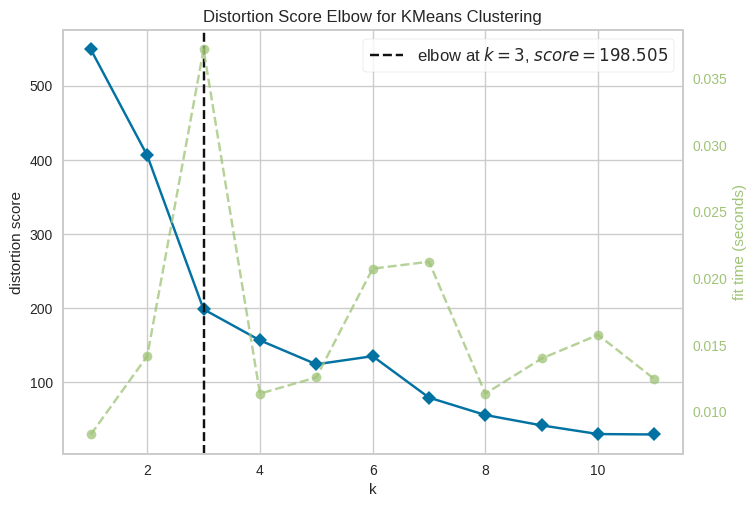

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12))
visualizer.fit(x_scaled)
visualizer.show()

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1
 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1]
 Our cluster centers are as follows
[[ 1.25163803 -0.23206726 -0.28423519]
 [-0.5673691  -0.26104838 -0.29599551]
 [-0.56011217  2.04494812  2.3788465 ]]


,Recency,Frequency,Monetary
cluster_pred,,,
0,57,57,57
1,106,106,106
2,20,20,20


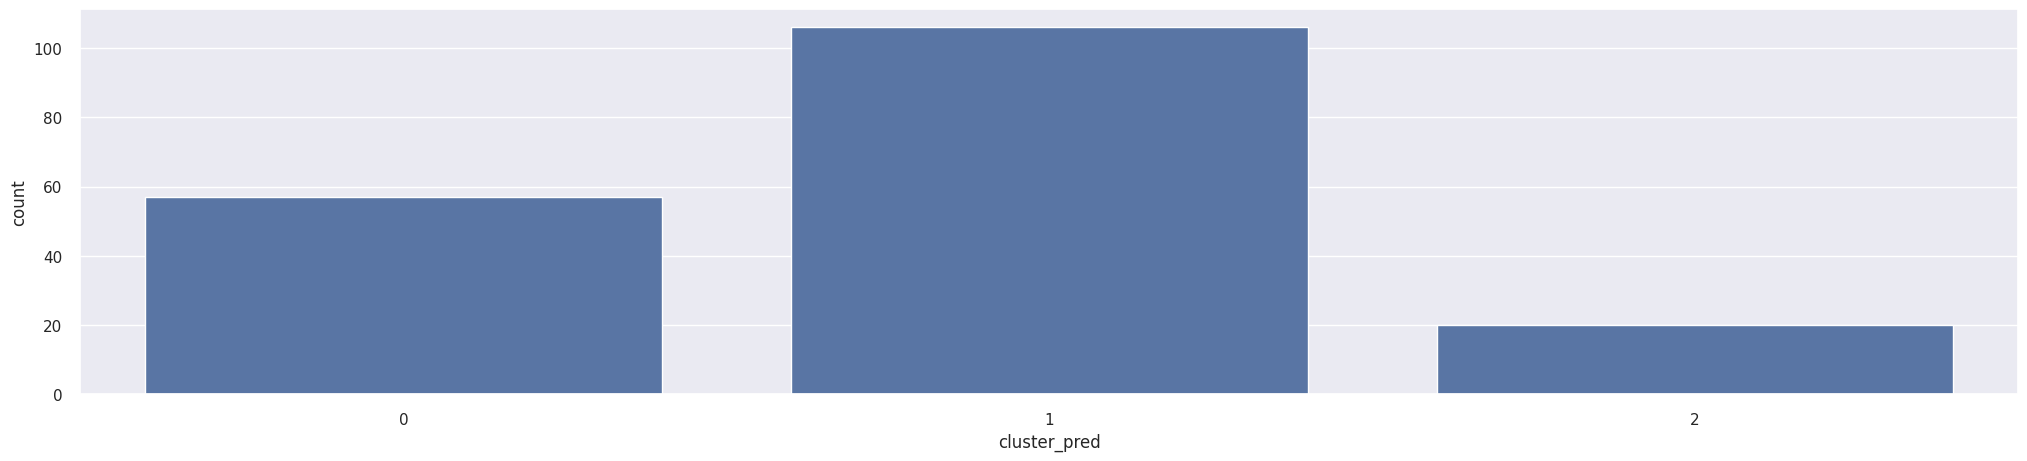

In [ ]:
kmeans_scaled = KMeans(3)
kmeans_scaled.fit(x_scaled)
identified_clusters = kmeans_scaled.fit_predict(rfm1)
clusters_scaled = rfm1.copy()
clusters_scaled['cluster_pred']=kmeans_scaled.fit_predict(x_scaled)
print(identified_clusters)
sns.set(style="darkgrid")
print(" Our cluster centers are as follows")
print(kmeans_scaled.cluster_centers_)
f, ax = plt.subplots(figsize=(25, 5))
ax = sns.countplot(x="cluster_pred", data=clusters_scaled)
clusters_scaled.groupby(['cluster_pred']).count()

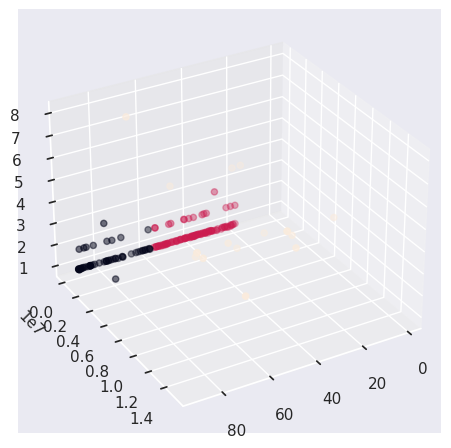

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
xline=clusters_scaled['Recency']
yline=clusters_scaled['Frequency']
zline=clusters_scaled['Monetary']

ax.scatter3D(xline, zline,yline,c=clusters_scaled['cluster_pred'])
ax.view_init(30, 60)

Silhouette Score: 0.521


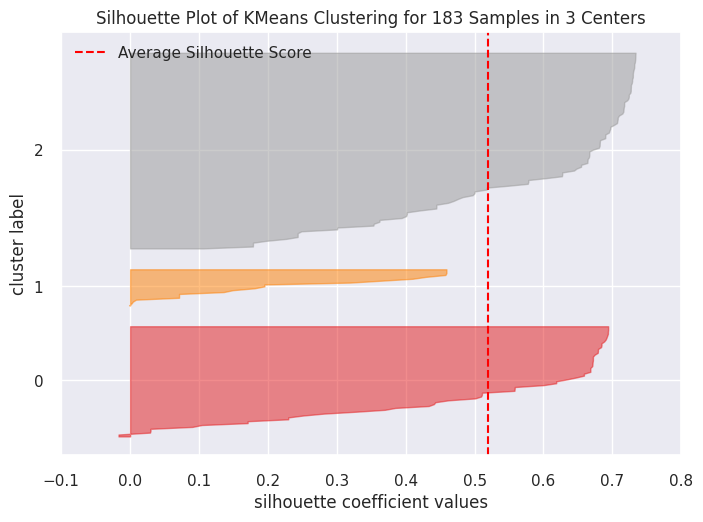

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 183 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
sil_score = silhouette_score(x_scaled, kmeans_scaled.labels_, metric='euclidean')
print('Silhouette Score: %.3f' % sil_score)

from yellowbrick.cluster import SilhouetteVisualizer
model = KMeans(3)
visualizer = SilhouetteVisualizer(model)
visualizer.fit(x_scaled)
visualizer.poof()

In [ ]:
rfm1['Cluster']= clusters_scaled['cluster_pred']
rfm1['Level']=rfm['Level']

rfm1.groupby('Cluster').agg({
    'Recency' : ['mean','min','max'],
    'Frequency' : ['mean','min','max'],
    'Monetary' : ['mean','min','max','count']
})

<ipython-input-24-70c5d032c838>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm1['Cluster']= clusters_scaled['cluster_pred']
<ipython-input-24-70c5d032c838>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm1['Level']=rfm['Level']


Recency         Frequency              Monetary                    \
              mean min max      mean min max          mean     min       max   
Cluster                                                                        
0        77.526316  59  90  1.175439   1   3  2.800877e+05  175000   2500000   
1        38.745283  20  57  1.150943   1   3  2.556132e+05  175000    650000   
2        38.900000   1  73  3.100000   2   8  5.822250e+06  875000  15200000   

               
        count  
Cluster        
0          57  
1         106  
2          20

In [ ]:
rfm1.head()

,Recency,Frequency,Monetary,Cluster,Level
ID_Pelanggan,,,,,
00100JOS,59,1,200000,0,Average
00101ARD,56,1,200000,1,Average
00102AMM,55,1,200000,1,Average
00103DEN,52,1,200000,1,Average
00104LIS,51,1,200000,1,Average


In [ ]:
rfm1.groupby(['Cluster','Level']).size()

Cluster  Level   
0        Average     38
         Good        14
         Inactive     5
1        Active      24
         Average     48
         Good        34
2        Active      20
dtype: int64

In [ ]:
rfm1.to_csv('K-Means Clustering.csv')